<a href="https://colab.research.google.com/github/vivianmay0298/Exercicios_Python_B6/blob/main/FISHMORPH_Order_Dataset_VivianMTamura_Noite_6B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importando bibliotecas para execução de funções e métodos para extração do dataset, formatação e tratamento de dados, treinamento de máquina e

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import kagglehub

2. Nesta seção é extraído o banco de dados em formato csv da plataforma kaggle e armazenado no local. Em seguida é organizado em uma estrutura tabular DataFrame para serem manipulados. Por fim é exibido as 5 primeiras linhas da tabela para melhor compreensão dos dados.

In [9]:
caminho = kagglehub.dataset_download("menegidio/fishmorph-dataset")
df = pd.read_csv(os.path.join(caminho, 'FISHMORPH_Order_Dataset.csv'))
df.head()

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cypriniformes
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Perciformes
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cypriniformes
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cypriniformes
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cypriniformes


3. Nestes 3 segmentos respectivamente é feito a EDA - análise exploratória de dados - com o objetivo de identificar as características das variáveis, os tipos de dados e se apresenta valores ausentes antes de prepararos dados para o treinamento do modelo.

In [10]:
df.describe()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt
count,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000
mean,22.004517,4.452438,0.549087,0.391665,0.381768,0.399786,0.571818,0.285316,0.189343,2.560795
std,33.612007,2.338235,0.094883,0.132814,0.194352,0.302658,0.117486,0.155629,0.056109,1.016659
min,1.200000,1.033084,0.159248,0.000000,0.000000,0.000000,0.224525,0.000000,0.000000,0.000000
25%,7.000000,3.139102,0.487993,0.293205,0.278014,0.257999,0.490052,0.193134,0.157972,1.999744
50%,12.600000,4.038851,0.546213,0.389429,0.406904,0.361436,0.564739,0.275039,0.183497,2.436329
75%,24.500000,5.002621,0.605125,0.486221,0.516001,0.490671,0.648039,0.368876,0.215031,2.919818
max,800.000000,43.728161,1.000000,1.026667,1.026316,7.060344,1.230105,0.857097,0.511113,15.452061


In [12]:
print(df.dtypes)

MBl      float64
BEl      float64
VEp      float64
REs      float64
OGp      float64
RMl      float64
BLs      float64
PFv      float64
PFs      float64
CPt      float64
Order     object
dtype: object


In [20]:
print(df.isnull().sum())

MBl      0
BEl      0
VEp      0
REs      0
OGp      0
RMl      0
BLs      0
PFv      0
PFs      0
CPt      0
Order    0
dtype: int64


4. Nestes 3 segmentos é preparado os dados para o treinamento de maquina, na qual, ao identificar os tipos de dados, é transformado a coluna 'Order' em códigos numéricos e separar o conjunto de dados em variáveis preditoras e variável-alvo.

In [22]:
df['Order'] = df['Order'].astype('category').cat.codes
df.head()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,8
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,22
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,8
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,8
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,8


In [24]:
x = df.loc[:, ~df.columns.isin(['Order'])]
print(x)

        MBl       BEl       VEp       REs       OGp       RMl       BLs  \
0     130.0  4.579113  0.622642  0.375019  0.622642  0.868659  0.484981   
1      11.5  2.796068  0.650700  0.353780  0.509800  0.411157  0.722461   
2       6.6  4.564329  0.518187  0.312002  0.203985  0.413221  0.591495   
3      10.9  4.390422  0.548247  0.244804  0.168959  0.324728  0.642991   
4      18.9  4.410271  0.542353  0.292058  0.183790  0.398567  0.685672   
...     ...       ...       ...       ...       ...       ...       ...   
8337   22.0  8.160515  0.742393  0.394320  0.307719  0.332283  0.793826   
8338   50.0  5.241134  0.600061  0.377792  0.293883  0.301585  0.617588   
8339    4.0  3.159920  0.453558  0.560501  0.533168  0.175106  0.470270   
8340  140.0  4.165031  0.545773  0.115646  0.471200  0.483810  0.498305   
8341  140.0  4.420704  0.600544  0.145919  0.422607  0.458131  0.476710   

           PFv       PFs       CPt  
0     0.273585  0.144108  3.348991  
1     0.330169  0.221095 

In [26]:
y = df['Order']
print(y)

0        8
1       22
2        8
3        8
4        8
        ..
8337    22
8338    22
8339     9
8340    28
8341    28
Name: Order, Length: 8342, dtype: int8


5. Neste seguimento é separado os dados entre treinamento e teste, das quais 80% dos dados são para ensinar o modelo e os 20% restantes, utilizadas para validar seu desempenho.

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

6. Neste seguimento é criado o pipeline para organização das etapas do treinamento em uma única estrutura, como também é padronizado os dados para que as escalas não torne o processo desproporcional. Assim, auxiliando no aprendizado dos padrões encontrados e separação de classe.

In [32]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

7. Neste segmento definimos os hiperparâmentros para achar a melhor combinação para o SVM testar.

In [34]:
grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

8. Neste segmento combinamos a pipeline e a grade de hiperparâmentros para comparar diferentes configurações por validação cruzada. Com cv=2, o conjunto de treinamento é dividido em duas partes.

In [37]:
grid_search = GridSearchCV(pipeline, grid, cv=2, scoring='accuracy', verbose=2, n_jobs=1)

9. Inicio do treinamento e busca de melhores hiperparâmentros

In [38]:
grid_search.fit(x_train, y_train)

Fitting 2 folds for each of 16 candidates, totalling 32 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


[CV] END ...svc__C=0.1, svc__gamma=scale, svc__kernel=linear; total time=   1.4s
[CV] END ...svc__C=0.1, svc__gamma=scale, svc__kernel=linear; total time=   2.0s
[CV] END ......svc__C=0.1, svc__gamma=scale, svc__kernel=rbf; total time=   2.3s
[CV] END ......svc__C=0.1, svc__gamma=scale, svc__kernel=rbf; total time=   1.4s
[CV] END ....svc__C=0.1, svc__gamma=auto, svc__kernel=linear; total time=   0.9s
[CV] END ....svc__C=0.1, svc__gamma=auto, svc__kernel=linear; total time=   0.8s
[CV] END .......svc__C=0.1, svc__gamma=auto, svc__kernel=rbf; total time=   1.4s
[CV] END .......svc__C=0.1, svc__gamma=auto, svc__kernel=rbf; total time=   1.4s
[CV] END .....svc__C=1, svc__gamma=scale, svc__kernel=linear; total time=   1.4s
[CV] END .....svc__C=1, svc__gamma=scale, svc__kernel=linear; total time=   1.3s
[CV] END ........svc__C=1, svc__gamma=scale, svc__kernel=rbf; total time=   1.4s
[CV] END ........svc__C=1, svc__gamma=scale, svc__kernel=rbf; total time=   1.2s
[CV] END ......svc__C=1, svc

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC())]),
             n_jobs=1,
             param_grid={'svc__C': [0.1, 1, 10, 100],
                         'svc__gamma': ['scale', 'auto'],
                         'svc__kernel': ['linear', 'rbf']},
             scoring='accuracy', verbose=2)

10. O resultado apresentou melhor desempenho com os hiperparâmetros C=10, gamma='scale' e kernel='rbf', alcançando uma acurácia média de 77,64% na validação cruzada. Após o treinamento, obteve 78,31% de acurácia no conjunto de teste

In [41]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(x_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(best_params)
print(best_score)
print(best_model)
print(accuracy_tuned)

{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
0.7764121337032861
Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(C=10))])
0.7831036548831636


11. Por fim, é criado a matriz confusão para demonstrar de maneira visual a análise o desempenho do modelo SVM. Podemos observar que a matriz confusão demonstrou que o modelo SVM apresentou melhor desempenho na classificação das classes 5, 7, 18 e 24, com destaque para a classe 18, que obteve o maior número de acertos. Porém, foram observados erros de classificação, principalmente com amostras das classes 5 e 24 sendo confundidas com a classe 7. Além disso, a baixa intensidade de cores em grande parte da matriz indica poucas classificações nessas categorias, o que pode estar relacionado à distribuição das amostras no conjunto de teste.

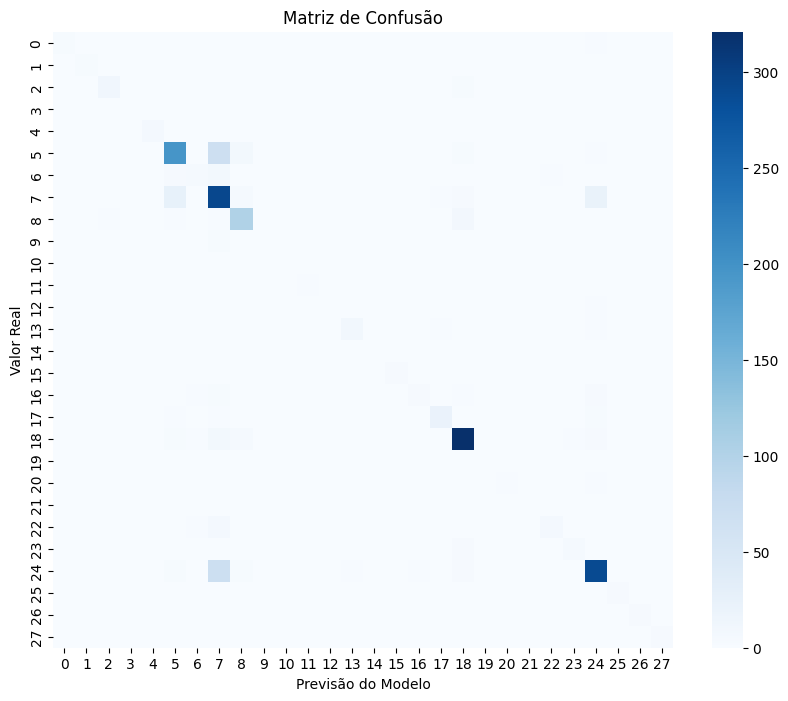

In [50]:
matriz = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz, cmap='Blues')

plt.title('Matriz de Confusão')
plt.ylabel('Valor Real')
plt.xlabel('Previsão do Modelo')

plt.show()